In [1]:
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [2]:
spark = (
    SparkSession.builder
    .appName("IDS_SparkLR")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.network.timeout", "600s")
    .config("spark.executor.heartbeatInterval", "60s")
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:8020")
    .config("spark.hadoop.dfs.client.use.datanode.hostname", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/21 17:24:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
HDFS_BASE        = "hdfs://namenode:8020"

SPLIT_DIR        = f"{HDFS_BASE}/user/spark/ids/processed/splits_stratified"
MODEL_HDFS       = f"{HDFS_BASE}/user/spark/ids/models/spark_lr"
MODEL_LOCAL      = "/opt/work/models/spark_lr"
OUTPUT_DIR       = "/opt/work/output"

LABEL_MAP_DIR    = f"{HDFS_BASE}/user/spark/ids/processed/label_mapping"
RF_IMPORT_DIR    = f"{HDFS_BASE}/user/spark/ids/processed/rf_feature_importance"

'''
Grid Search:
lr.regParam, [0.01, 0.1, 0.2]
lr.elasticNetParam, [0.0, 0.5]
'''
# LR hyperparams
LR_MAX_ITER             = 150
LR_REG_PARAM            = 0.01 # based on grid search
LR_ELASTIC_NET_PARAM    = 0.5 # based on grid search
LR_FAMILY               = "multinomial"
LABEL_COL               = "label_idx"
WEIGHT_COL              = "class_weight"
RANDOM_STATE            = 42

LABEL_COL     = "label_idx"

# Load label mapping
label_map_df = (spark.read.option("header", True).csv(LABEL_MAP_DIR)
                .withColumn("label_idx", F.col("label_idx").cast("int"))
                .orderBy("label_idx"))

ATTACK_NAMES = {r["label_idx"]: r["label_name"] for r in label_map_df.collect()}

print(f"Loaded label mapping: {len(ATTACK_NAMES)} classes")
print(list(ATTACK_NAMES.items()))

# Load top-K features from Spark RF importance
TOP_K = 30

rf_imp_df = (spark.read.option("header", True).csv(RF_IMPORT_DIR)
             .withColumn("importance", F.col("importance").cast("double"))
             .orderBy(F.desc("importance")))

FEATURE_COLS_RAW = [r["feature"] for r in rf_imp_df.limit(TOP_K).collect()]

print(f"Top-{TOP_K} features from RF artifact:")
print(FEATURE_COLS_RAW)

Loaded label mapping: 15 classes
[(0, 'Benign'), (1, 'DDOS attack-HOIC'), (2, 'DDoS attacks-LOIC-HTTP'), (3, 'DoS attacks-Hulk'), (4, 'Bot'), (5, 'FTP-BruteForce'), (6, 'SSH-Bruteforce'), (7, 'Infilteration'), (8, 'DoS attacks-SlowHTTPTest'), (9, 'DoS attacks-GoldenEye'), (10, 'DoS attacks-Slowloris'), (11, 'DDOS attack-LOIC-UDP'), (12, 'Brute Force -Web'), (13, 'Brute Force -XSS'), (14, 'SQL Injection')]
Top-30 features from RF artifact:
['Init Fwd Win Byts', 'Dst Port', 'Fwd Seg Size Min', 'timestamp_unix', 'Fwd Pkt Len Max', 'Fwd Header Len', 'Subflow Fwd Byts', 'TotLen Fwd Pkts', 'Flow Duration', 'Flow IAT Max', 'Fwd IAT Min', 'Flow IAT Min', 'Fwd Pkts/s', 'Fwd Seg Size Avg', 'Flow Pkts/s', 'Flow IAT Mean', 'Fwd IAT Max', 'Fwd Pkt Len Mean', 'Init Bwd Win Byts', 'Fwd IAT Mean', 'Fwd IAT Tot', 'Fwd Pkt Len Std', 'Bwd Pkt Len Mean', 'Pkt Len Std', 'Bwd Pkts/s', 'Bwd Seg Size Avg', 'Bwd Pkt Len Std', 'Tot Fwd Pkts', 'Pkt Size Avg', 'Subflow Fwd Pkts']


In [4]:
train_df = spark.read.parquet(f"{SPLIT_DIR}/train")
val_df   = spark.read.parquet(f"{SPLIT_DIR}/val")
test_df  = spark.read.parquet(f"{SPLIT_DIR}/test")

cols = set(train_df.columns)

FEATURE_COLS = []
missing = []

for c in FEATURE_COLS_RAW:
    if c in cols and c != "timestamp_unix": # might cause leak
        FEATURE_COLS.append(c)
    else:
        missing.append(c)

if missing:
    print("Missing RF-selected features (will be skipped):", missing)

keep_cols = FEATURE_COLS + [LABEL_COL]

train_df = train_df.select(keep_cols)
val_df   = val_df.select(keep_cols)
test_df  = test_df.select(keep_cols)

n_train = train_df.count()
n_val   = val_df.count()
n_test  = test_df.count()
n_total = n_train + n_val + n_test

print(f"Using {len(FEATURE_COLS)} features:", FEATURE_COLS)
print(f"Train  : {n_train:>10,}  ({n_train/n_total*100:.1f}%)")
print(f"Val    : {n_val:>10,}  ({n_val/n_total*100:.1f}%)")
print(f"Test   : {n_test:>10,}  ({n_test/n_total*100:.1f}%)")
print(f"Total  : {n_total:>10,}")

Missing RF-selected features (will be skipped): ['timestamp_unix']
Using 29 features: ['Init Fwd Win Byts', 'Dst Port', 'Fwd Seg Size Min', 'Fwd Pkt Len Max', 'Fwd Header Len', 'Subflow Fwd Byts', 'TotLen Fwd Pkts', 'Flow Duration', 'Flow IAT Max', 'Fwd IAT Min', 'Flow IAT Min', 'Fwd Pkts/s', 'Fwd Seg Size Avg', 'Flow Pkts/s', 'Flow IAT Mean', 'Fwd IAT Max', 'Fwd Pkt Len Mean', 'Init Bwd Win Byts', 'Fwd IAT Mean', 'Fwd IAT Tot', 'Fwd Pkt Len Std', 'Bwd Pkt Len Mean', 'Pkt Len Std', 'Bwd Pkts/s', 'Bwd Seg Size Avg', 'Bwd Pkt Len Std', 'Tot Fwd Pkts', 'Pkt Size Avg', 'Subflow Fwd Pkts']
Train  :  4,026,287  (70.0%)
Val    :    861,484  (15.0%)
Test   :    863,597  (15.0%)
Total  :  5,751,368


,label_idx,count,label_name,pct
0,0.0,2101779,Benign,52.201
1,1.0,480487,DDOS attack-HOIC,11.934
2,2.0,403712,DDoS attacks-LOIC-HTTP,10.027
3,3.0,323545,DoS attacks-Hulk,8.036
4,4.0,200481,Bot,4.979
5,5.0,135308,FTP-BruteForce,3.361
6,6.0,131275,SSH-Bruteforce,3.260
7,7.0,112995,Infilteration,2.806
8,8.0,98038,DoS attacks-SlowHTTPTest,2.435
9,9.0,29174,DoS attacks-GoldenEye,0.725


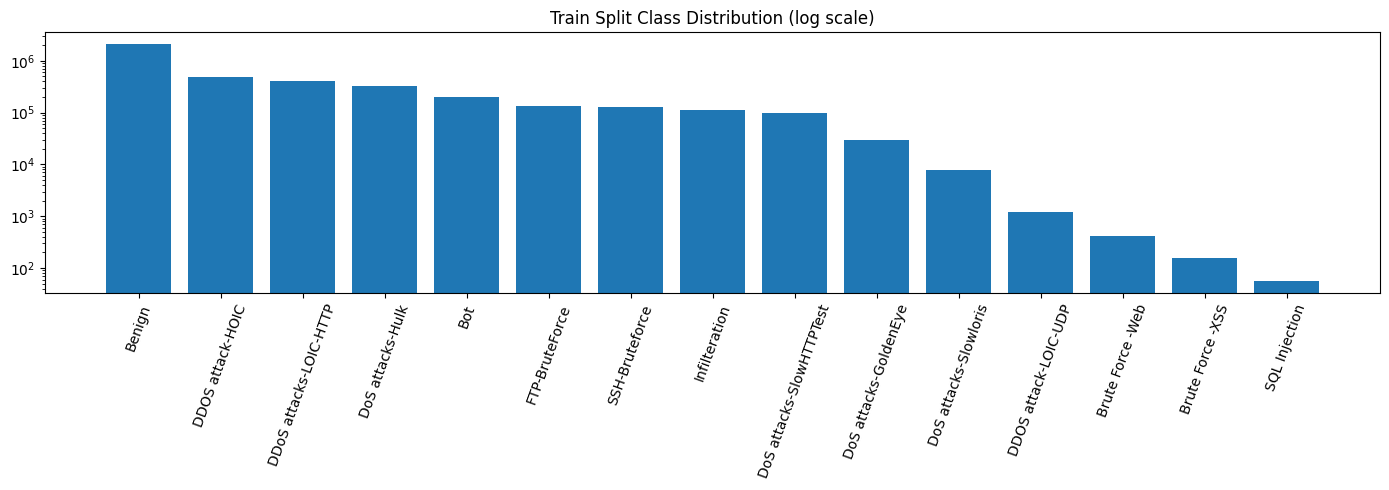

In [5]:
dist_train = (train_df.groupBy(LABEL_COL).count().orderBy(LABEL_COL).toPandas())
dist_train["label_name"] = dist_train[LABEL_COL].map(ATTACK_NAMES)

dist_train["pct"] = (dist_train["count"] / dist_train["count"].sum() * 100).round(3)
display(dist_train)

plt.figure(figsize=(14,5))
plt.bar(dist_train["label_name"], dist_train["count"])
plt.xticks(rotation=70)
plt.yscale("log")
plt.title("Train Split Class Distribution (log scale)")
plt.tight_layout()
plt.show()

In [6]:
class_counts = dist_train["count"]

# Oversample the three zero-recall classes to a minimum floor in train
MIN_SAMPLES = 5000  # target minimum per class in training

tiny_classes = [c for c, cnt in class_counts.items() if cnt < MIN_SAMPLES]
print(f"Oversampling {len(tiny_classes)} tiny classes to {MIN_SAMPLES} samples each: "
      f"{[ATTACK_NAMES[c] for c in tiny_classes]}")

oversampled_parts = [train_df]
for c in tiny_classes:
    class_df = train_df.filter(F.col(LABEL_COL) == c)
    current = class_counts[c]
    ratio = MIN_SAMPLES / current
    # withReplacement=True because we have fewer samples than target
    oversampled_parts.append(class_df.sample(withReplacement=True, fraction=ratio, seed=RANDOM_STATE))

train_df = oversampled_parts[0]
for part in oversampled_parts[1:]:
    train_df = train_df.union(part)

# Recompute counts after oversampling
new_counts = (train_df.groupBy(LABEL_COL).count().toPandas().set_index(LABEL_COL)["count"].to_dict())
print("Counts after oversampling:")
for c in sorted(new_counts):
    print(f"  {ATTACK_NAMES[c]:30s}  {new_counts[c]:>8,}")

Oversampling 4 tiny classes to 5000 samples each: ['DDOS attack-LOIC-UDP', 'Brute Force -Web', 'Brute Force -XSS', 'SQL Injection']


[Stage 27:============================================>           (20 + 1) / 25]

Counts after oversampling:
  Benign                          2,101,779
  DDOS attack-HOIC                 480,487
  DDoS attacks-LOIC-HTTP           403,712
  DoS attacks-Hulk                 323,545
  Bot                              200,481
  FTP-BruteForce                   135,308
  SSH-Bruteforce                   131,275
  Infilteration                    112,995
  DoS attacks-SlowHTTPTest          98,038
  DoS attacks-GoldenEye             29,174
  DoS attacks-Slowloris              7,667
  DDOS attack-LOIC-UDP               6,303
  Brute Force -Web                   5,517
  Brute Force -XSS                   5,216
  SQL Injection                      5,094


In [7]:
# ── Inverse-frequency class weights ─────────────────────────────────────────
# Without this, LR loss is dominated by Benign (largest class) and the model
# learns to predict Benign well at the expense of minority attack classes.
n_classes = len(ATTACK_NAMES)

class_counts = (
    train_df.groupBy(LABEL_COL)
    .count()
    .toPandas()
    .set_index(LABEL_COL)["count"]
    .to_dict()
)

MAX_WEIGHT = 15.0   # raise cap for tiny classes

raw_weights = {
    c: n_train / (n_classes * cnt)
    for c, cnt in class_counts.items()
}

class_weights = {
    c: min(w, MAX_WEIGHT)
    for c, w in raw_weights.items()
}

# Benign floor — don't let it drop below 0.5
# Without this, the dominant class gets ignored and everything collapses into mid-size classes
BENIGN_CLASS = [c for c, name in ATTACK_NAMES.items() if "benign" in name.lower()][0]
class_weights[BENIGN_CLASS] = max(class_weights[BENIGN_CLASS], 0.4)

weight_expr = F.lit(1.0)
for c, w in class_weights.items():
    weight_expr = F.when(F.col(LABEL_COL) == c, float(w)).otherwise(weight_expr)

train_df = train_df.withColumn(WEIGHT_COL, weight_expr)
train_df = train_df.select(FEATURE_COLS + [LABEL_COL, WEIGHT_COL])

print("Class weights (inverse frequency):")
for c in sorted(class_weights):
    print(f"  {ATTACK_NAMES[c]:30s}  count={class_counts[c]:>9,}  weight={class_weights[c]:.4f}")

[Stage 30:=====================================================>  (24 + 1) / 25]

Class weights (inverse frequency):
  Benign                          count=2,101,779  weight=0.4000
  DDOS attack-HOIC                count=  480,487  weight=0.5586
  DDoS attacks-LOIC-HTTP          count=  403,712  weight=0.6649
  DoS attacks-Hulk                count=  323,545  weight=0.8296
  Bot                             count=  200,481  weight=1.3389
  FTP-BruteForce                  count=  135,308  weight=1.9838
  SSH-Bruteforce                  count=  131,275  weight=2.0447
  Infilteration                   count=  112,995  weight=2.3755
  DoS attacks-SlowHTTPTest        count=   98,038  weight=2.7379
  DoS attacks-GoldenEye           count=   29,174  weight=9.2006
  DoS attacks-Slowloris           count=    7,667  weight=15.0000
  DDOS attack-LOIC-UDP            count=    6,303  weight=15.0000
  Brute Force -Web                count=    5,517  weight=15.0000
  Brute Force -XSS                count=    5,216  weight=15.0000
  SQL Injection                   count=    5,094  

In [8]:
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol="features_raw",
    handleInvalid="skip",
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True,
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol=LABEL_COL,
    weightCol=WEIGHT_COL,
    predictionCol="prediction",
    probabilityCol="probability",
    family=LR_FAMILY,
    maxIter=LR_MAX_ITER,
    regParam=LR_REG_PARAM,
    elasticNetParam=LR_ELASTIC_NET_PARAM,
    tol=1e-6,
)

pipeline = Pipeline(stages=[assembler, scaler, lr])
print("Pipeline ready")

Pipeline ready


In [9]:
print(f"Training on {n_train:,} rows | {len(FEATURE_COLS)} features | {len(ATTACK_NAMES)} classes")
print(f"LR: family={LR_FAMILY}, maxIter={LR_MAX_ITER}, regParam={LR_REG_PARAM}, elasticNetParam={LR_ELASTIC_NET_PARAM}")
print()

train_df.cache()
_ = train_df.count()  # materialize cache

t0 = time.time()
model = pipeline.fit(train_df)
train_time_s = time.time() - t0

print(f"Training complete: {train_time_s:.1f}s  ({train_time_s/60:.2f} min)")

Training on 4,026,287 rows | 29 features | 15 classes
LR: family=multinomial, maxIter=150, regParam=0.01, elasticNetParam=0.5



26/02/21 17:24:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/02/21 17:25:31 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

Training complete: 919.3s  (15.32 min)


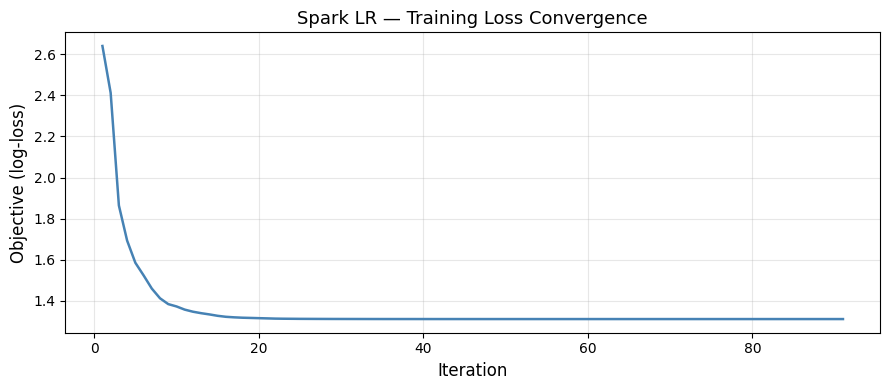

Converged in 91 iterations
Initial loss : 2.6405
Final loss   : 1.311216


In [10]:
lr_model = model.stages[-1]
loss_history = lr_model.summary.objectiveHistory

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(loss_history)+1), loss_history, linewidth=1.8, color="steelblue")
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Objective (log-loss)", fontsize=12)
ax.set_title("Spark LR — Training Loss Convergence", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/lr_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Converged in {len(loss_history)} iterations")
print(f"Initial loss : {loss_history[0]:.4f}")
print(f"Final loss   : {loss_history[-1]:.6f}")

In [11]:
train_df.unpersist()

DataFrame[Init Fwd Win Byts: double, Dst Port: double, Fwd Seg Size Min: double, Fwd Pkt Len Max: double, Fwd Header Len: double, Subflow Fwd Byts: double, TotLen Fwd Pkts: double, Flow Duration: double, Flow IAT Max: double, Fwd IAT Min: double, Flow IAT Min: double, Fwd Pkts/s: double, Fwd Seg Size Avg: double, Flow Pkts/s: double, Flow IAT Mean: double, Fwd IAT Max: double, Fwd Pkt Len Mean: double, Init Bwd Win Byts: double, Fwd IAT Mean: double, Fwd IAT Tot: double, Fwd Pkt Len Std: double, Bwd Pkt Len Mean: double, Pkt Len Std: double, Bwd Pkts/s: double, Bwd Seg Size Avg: double, Bwd Pkt Len Std: double, Tot Fwd Pkts: double, Pkt Size Avg: double, Subflow Fwd Pkts: double, label_idx: double, class_weight: double]

In [12]:
def evaluate_overall(preds, label_col):
    metrics = {}
    for metric in ["accuracy", "f1", "weightedPrecision", "weightedRecall"]:
        ev = MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol="prediction", metricName=metric
        )
        metrics[metric] = ev.evaluate(preds)
    return metrics

t_eval = time.time()
val_preds = model.transform(val_df)
val_metrics = evaluate_overall(val_preds, LABEL_COL)
val_eval_time = time.time() - t_eval

print(f"Validation Results ({val_eval_time:.1f}s):")
for k, v in val_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

[Stage 288:======================================>                  (2 + 1) / 3]

Validation Results (39.3s):
  accuracy            : 0.8480
  f1                  : 0.8362
  weightedPrecision   : 0.8432
  weightedRecall      : 0.8480


In [13]:
t_eval = time.time()
test_preds = model.transform(test_df)
test_metrics = evaluate_overall(test_preds, LABEL_COL)
eval_time_s = time.time() - t_eval

print(f"Test Set Results ({eval_time_s:.1f}s):")
for k, v in test_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

[Stage 296:======================================>                  (2 + 1) / 3]

Test Set Results (31.0s):
  accuracy            : 0.8469
  f1                  : 0.8351
  weightedPrecision   : 0.8416
  weightedRecall      : 0.8469


In [14]:
# Quick confusion diagnosis on val set
cm = (
    val_preds
    .groupBy(F.col(LABEL_COL).alias("true"), F.col("prediction").cast("int").alias("pred"))
    .count()
    .orderBy("true", "pred")
    .toPandas()
)

# Per-class recall (what % of each true class is correctly predicted)
for c in sorted(ATTACK_NAMES):
    total_c = cm[cm["true"] == c]["count"].sum()
    correct = cm[(cm["true"] == c) & (cm["pred"] == c)]["count"].sum()
    recall = correct / total_c if total_c > 0 else 0
    dominant_pred = cm[cm["true"] == c].sort_values("count", ascending=False).iloc[0]["pred"]
    print(f"  {ATTACK_NAMES[c]:30s}  recall={recall:.3f}  most_predicted_as={ATTACK_NAMES.get(dominant_pred, dominant_pred)}")

  Benign                          recall=0.911  most_predicted_as=Benign
  DDOS attack-HOIC                recall=1.000  most_predicted_as=DDOS attack-HOIC
  DDoS attacks-LOIC-HTTP          recall=0.790  most_predicted_as=DDoS attacks-LOIC-HTTP
  DoS attacks-Hulk                recall=0.946  most_predicted_as=DoS attacks-Hulk
  Bot                             recall=0.485  most_predicted_as=Benign
  FTP-BruteForce                  recall=0.784  most_predicted_as=FTP-BruteForce
  SSH-Bruteforce                  recall=0.784  most_predicted_as=SSH-Bruteforce
  Infilteration                   recall=0.048  most_predicted_as=Benign
  DoS attacks-SlowHTTPTest        recall=0.550  most_predicted_as=DoS attacks-SlowHTTPTest
  DoS attacks-GoldenEye           recall=0.766  most_predicted_as=DoS attacks-GoldenEye
  DoS attacks-Slowloris           recall=0.673  most_predicted_as=DoS attacks-Slowloris
  DDOS attack-LOIC-UDP            recall=1.000  most_predicted_as=DDOS attack-LOIC-UDP
  Brute Fo

In [15]:
def per_class_metrics(preds_df, label_col, attack_names):
    total = preds_df.count()
    rows  = []
    for c in range(len(attack_names)):
        tp = preds_df.filter((F.col(label_col)==c) & (F.col("prediction")==c)).count()
        fp = preds_df.filter((F.col(label_col)!=c) & (F.col("prediction")==c)).count()
        fn = preds_df.filter((F.col(label_col)==c) & (F.col("prediction")!=c)).count()
        tn = total - tp - fp - fn
        prec = tp/(tp+fp)          if (tp+fp)      else 0
        rec  = tp/(tp+fn)          if (tp+fn)      else 0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0
        rows.append({
            "Class"    : c,
            "Attack"   : attack_names[c],
            "TP": tp, "FP": fp, "FN": fn,
            "Precision": round(prec, 4),
            "Recall"   : round(rec,  4),
            "F1-Score" : round(f1,   4),
        })
    return pd.DataFrame(rows)

metrics_df = per_class_metrics(test_preds, LABEL_COL, ATTACK_NAMES)

print("Per-Class Metrics (Test Set):")
print(metrics_df[["Class","Attack","Precision","Recall","F1-Score"]].to_string(index=False))
print(f"\nMean F1    : {metrics_df['F1-Score'].mean():.4f}")
print(f"Macro Prec : {metrics_df['Precision'].mean():.4f}")
print(f"Macro Rec  : {metrics_df['Recall'].mean():.4f}")

metrics_df.to_csv(f"{OUTPUT_DIR}/lr_per_class_metrics.csv", index=False)

Per-Class Metrics (Test Set):
 Class                   Attack  Precision  Recall  F1-Score
     0                   Benign     0.8724  0.9098    0.8907
     1         DDOS attack-HOIC     0.9510  1.0000    0.9749
     2   DDoS attacks-LOIC-HTTP     0.7813  0.7898    0.7855
     3         DoS attacks-Hulk     0.8317  0.9441    0.8843
     4                      Bot     0.6797  0.4798    0.5625
     5           FTP-BruteForce     0.6842  0.7850    0.7312
     6           SSH-Bruteforce     0.9909  0.7862    0.8768
     7            Infilteration     0.6123  0.0460    0.0856
     8 DoS attacks-SlowHTTPTest     0.6265  0.5498    0.5857
     9    DoS attacks-GoldenEye     0.5558  0.7724    0.6465
    10    DoS attacks-Slowloris     0.9505  0.6832    0.7949
    11     DDOS attack-LOIC-UDP     0.3236  1.0000    0.4890
    12         Brute Force -Web     0.0244  0.2083    0.0437
    13         Brute Force -XSS     0.0111  0.3488    0.0215
    14            SQL Injection     0.0000  0.0000    0

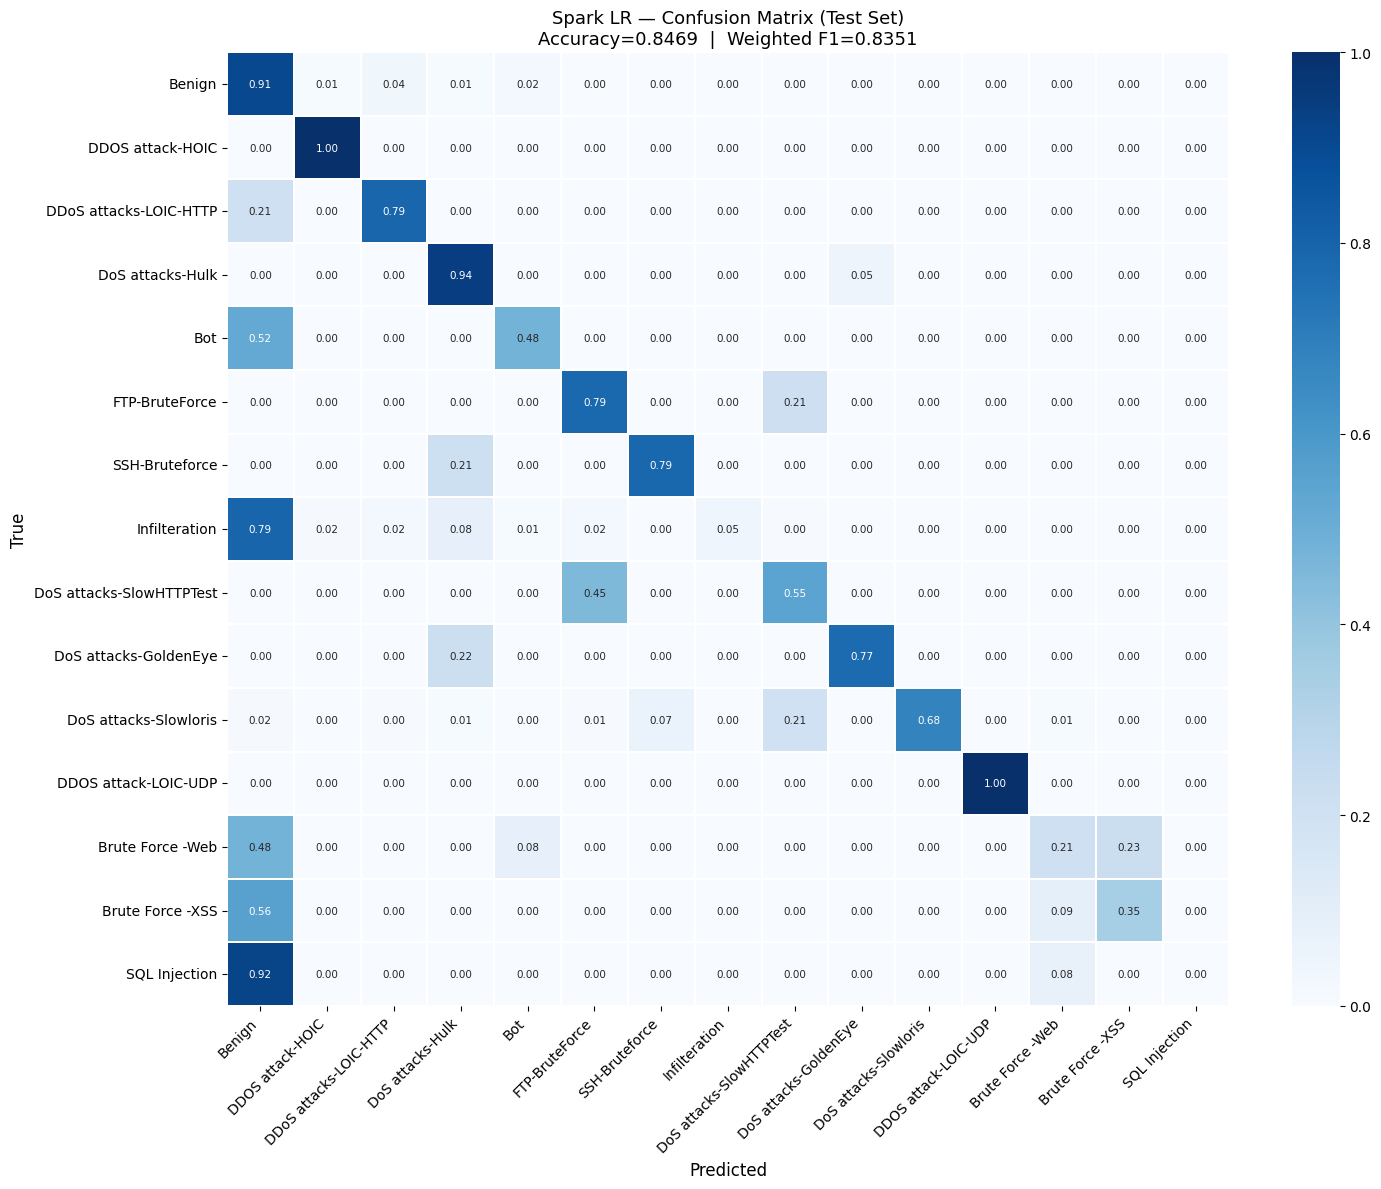

In [16]:
import seaborn as sns

cm_raw = (
    test_preds
    .groupBy(LABEL_COL, "prediction")
    .count()
    .toPandas()
)

n_cls = len(ATTACK_NAMES)
cm = np.zeros((n_cls, n_cls), dtype=np.int64)
for _, row in cm_raw.iterrows():
    r, c = int(row[LABEL_COL]), int(row["prediction"])
    if 0 <= r < n_cls and 0 <= c < n_cls:
        cm[r][c] = int(row["count"])

# Row-normalise (diagonal = per-class recall)
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm / row_sums

labels = [ATTACK_NAMES[i] for i in range(n_cls)]

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f",
    xticklabels=labels, yticklabels=labels,
    cmap="Blues", linewidths=0.3, ax=ax,
    annot_kws={"size": 7.5}, vmin=0, vmax=1,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Spark LR — Confusion Matrix (Test Set)\n"
    f"Accuracy={test_metrics['accuracy']:.4f}  |  Weighted F1={test_metrics['f1']:.4f}",
    fontsize=13
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/lr_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
print("=" * 60)
print("  SPARK LR — FINAL SUMMARY")
print("=" * 60)
print(f"  Features        : {len(FEATURE_COLS)} (timestamp_unix excluded)")
print(f"  Oversampling    : tiny classes → 5,000 min samples")
print(f"  Class weights   : inv-freq, floor=0.5 Benign, cap=15.0")
print(f"  regParam        : {LR_REG_PARAM}  |  elasticNet: {LR_ELASTIC_NET_PARAM}")
print(f"  Training time   : {train_time_s/60:.2f} min")
print(f"  Iterations      : {len(loss_history)}")
print()
print(f"  {'Metric':22s}  {'Val':>8}  {'Test':>8}  {'Paper':>8}")
print(f"  {'-'*52}")
for m, label in [("accuracy","Accuracy"), ("f1","Weighted F1"),
                 ("weightedPrecision","Weighted Prec"), ("weightedRecall","Weighted Recall")]:
    print(f"  {label:22s}  {val_metrics[m]:8.4f}  {test_metrics[m]:8.4f}  {'~0.999':>8}")
print()
print(f"  Classes recall > 0.9 : {(metrics_df['Recall'] > 0.9).sum()}/{len(ATTACK_NAMES)}")
print(f"  Classes recall < 0.5 : {(metrics_df['Recall'] < 0.5).sum()}/{len(ATTACK_NAMES)}")
print(f"  Note: Infiltration and web attacks are linearly inseparable")
print(f"        from Benign — motivates CNN/LSTM models.")
print("=" * 60)

# Save model
model.write().overwrite().save(MODEL_HDFS)
model.write().overwrite().save(MODEL_LOCAL)
print(f"\nModel saved: {MODEL_HDFS}")

# Save metadata
metadata = {
    "model"             : "Spark LR",
    "n_features"        : len(FEATURE_COLS),
    "features"          : FEATURE_COLS,
    "timestamp_removed" : "timestamp_unix" not in FEATURE_COLS,
    "oversampling_floor": MIN_SAMPLES,
    "weight_config"     : {
        "method"        : "inverse-frequency",
        "max_weight"    : MAX_WEIGHT,
        "benign_floor"  : class_weights[BENIGN_CLASS],
    },
    "hyperparameters"   : {
        "family"         : LR_FAMILY,
        "maxIter"        : LR_MAX_ITER,
        "regParam"       : LR_REG_PARAM,
        "elasticNetParam": LR_ELASTIC_NET_PARAM,
        "scaler"         : "StandardScaler(withMean=True, withStd=True)",
    },
    "data_split"        : {"train": n_train, "val": n_val, "test": n_test},
    "class_weights"     : {ATTACK_NAMES[c]: round(w, 6) for c, w in class_weights.items()},
    "class_counts_train": {ATTACK_NAMES[c]: int(cnt) for c, cnt in class_counts.items()},
    "results_val"       : {k: round(v, 6) for k, v in val_metrics.items()},
    "results_test"      : {k: round(v, 6) for k, v in test_metrics.items()},
    "per_class_metrics" : metrics_df[["Attack","Precision","Recall","F1-Score"]].to_dict(orient="records"),
    "training_time_s"   : round(train_time_s, 2),
    "training_time_min" : round(train_time_s / 60, 2),
    "lr_iterations"     : len(loss_history),
    "converged"         : len(loss_history) < LR_MAX_ITER,
    "timestamp"         : time.strftime("%Y-%m-%d %H:%M:%S"),
}

with open(f"{OUTPUT_DIR}/lr_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved: {OUTPUT_DIR}/lr_metadata.json")

  SPARK LR — FINAL SUMMARY
  Features        : 29 (timestamp_unix excluded)
  Oversampling    : tiny classes → 5,000 min samples
  Class weights   : inv-freq, floor=0.5 Benign, cap=15.0
  regParam        : 0.01  |  elasticNet: 0.5
  Training time   : 15.32 min
  Iterations      : 91

  Metric                       Val      Test     Paper
  ----------------------------------------------------
  Accuracy                  0.8480    0.8469    ~0.999
  Weighted F1               0.8362    0.8351    ~0.999
  Weighted Prec             0.8432    0.8416    ~0.999
  Weighted Recall           0.8480    0.8469    ~0.999

  Classes recall > 0.9 : 4/15
  Classes recall < 0.5 : 5/15
  Note: Infiltration and web attacks are linearly inseparable
        from Benign — motivates CNN/LSTM models.



Model saved: hdfs://namenode:8020/user/spark/ids/models/spark_lr
Metadata saved: /opt/work/output/lr_metadata.json


In [18]:
spark.stop()